In [1]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
# Import all necessary libraries
import pandas as pd                        
import numpy as np                         
from sklearn.preprocessing import (
    StandardScaler,                       
    LabelEncoder,                         
    MinMaxScaler                           
)
import matplotlib.pyplot as plt           
import seaborn as sns                     
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# Load Dataset

In [5]:
# Load the scraped books dataset from Task 1
df = pd.read_csv(r'C:\Users\MY-PC\Documents\Internship\Level 01\books_data.csv')

# Display basic information about the dataset
print("Dataset loaded successfully!")
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Shape: 200 rows x 5 columns

First 5 rows:


,Title,Price (£),Rating (out of 5),Availability,Book URL
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...


# Explore Raw Data

In [6]:
# Check data types and non-null counts
print("Dataset Info:")
print(df.info())

# Check summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              200 non-null    object 
 1   Price (£)          200 non-null    float64
 2   Rating (out of 5)  200 non-null    int64  
 3   Availability       200 non-null    object 
 4   Book URL           200 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 7.9+ KB
None

Summary Statistics:
        Price (£)  Rating (out of 5)
count  200.000000         200.000000
mean    34.796250           2.865000
std     14.119272           1.451658
min     10.160000           1.000000
25%     21.990000           2.000000
50%     35.640000           3.000000
75%     46.110000           4.000000
max     59.640000           5.000000

Missing Values:
Title                0
Price (£)            0
Rating (out of 5)    0
Availability         0
Book URL        

 # Handle Missing Data

In [7]:
# Check missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Missing Value Percentage:")
print(missing_percent)

# Fill missing numerical values with median
df['Price (£)'].fillna(df['Price (£)'].median(), inplace=True)

# Fill missing rating values with mode (most common rating)
df['Rating (out of 5)'].fillna(df['Rating (out of 5)'].mode()[0], inplace=True)

# Drop rows where Title is missing (cannot impute text)
df.dropna(subset=['Title'], inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing Value Percentage:
Title                0.0
Price (£)            0.0
Rating (out of 5)    0.0
Availability         0.0
Book URL             0.0
dtype: float64

Missing values after handling:
Title                0
Price (£)            0
Rating (out of 5)    0
Availability         0
Book URL             0
dtype: int64


# Detect & Remove Outliers

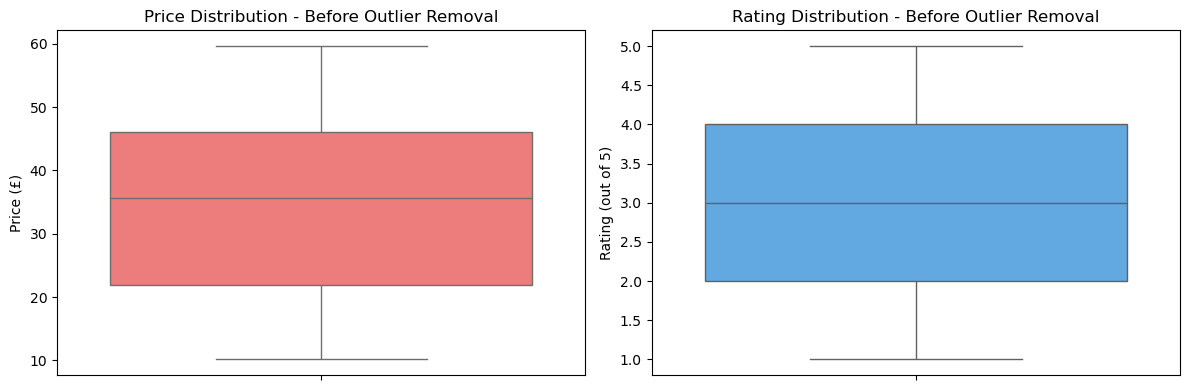

Outliers removed from 'Price (£)': 0 rows

Dataset shape after outlier removal: (200, 5)


In [8]:
# Visualize outliers using boxplot before removal
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Price (£)'], color='#ff6b6b')
plt.title('Price Distribution - Before Outlier Removal')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Rating (out of 5)'], color='#4dabf7')
plt.title('Rating Distribution - Before Outlier Removal')

plt.tight_layout()
plt.savefig('outliers_before.png', dpi=150)
plt.show()

# Remove outliers using IQR method
def remove_outliers(df, column):
    """
    Remove outliers from a column using the IQR method
    IQR = Interquartile Range (Q3 - Q1)
    """
    Q1 = df[column].quantile(0.25)   # 25th percentile
    Q3 = df[column].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                    # Interquartile range

    lower_bound = Q1 - 1.5 * IQR    # Lower boundary
    upper_bound = Q3 + 1.5 * IQR    # Upper boundary

    # Keep only rows within bounds
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    removed = len(df) - len(filtered_df)
    print(f"Outliers removed from '{column}': {removed} rows")
    
    return filtered_df

# Apply outlier removal
df = remove_outliers(df, 'Price (£)')

print(f"\nDataset shape after outlier removal: {df.shape}")

# Encode Categorical Variables

In [9]:
# --- Label Encoding for Availability column ---
# Converts text categories to numbers
# e.g. "In stock" -> 1, "Out of stock" -> 0

le = LabelEncoder()
df['Availability_Encoded'] = le.fit_transform(df['Availability'])

print("Label Encoding - Availability:")
print(df[['Availability', 'Availability_Encoded']].drop_duplicates())

# --- One-Hot Encoding for Rating column ---
# Creates separate columns for each rating value
# e.g. Rating_1, Rating_2, Rating_3, Rating_4, Rating_5

df_encoded = pd.get_dummies(df, columns=['Rating (out of 5)'], prefix='Rating')

print("\nColumns after One-Hot Encoding:")
print(df_encoded.columns.tolist())

Label Encoding - Availability:
  Availability  Availability_Encoded
0     In stock                     0

Columns after One-Hot Encoding:
['Title', 'Price (£)', 'Availability', 'Book URL', 'Availability_Encoded', 'Rating_1', 'Rating_2', 'Rating_3', 'Rating_4', 'Rating_5']


# Normalize & Standardize Data

In [10]:
# --- Normalization using MinMaxScaler ---
# Scales data between 0 and 1
# Formula: (x - min) / (max - min)

scaler_minmax = MinMaxScaler()
df['Price_Normalized'] = scaler_minmax.fit_transform(df[['Price (£)']])

# --- Standardization using StandardScaler ---
# Scales data to have mean=0 and std=1
# Formula: (x - mean) / std

scaler_standard = StandardScaler()
df['Price_Standardized'] = scaler_standard.fit_transform(df[['Price (£)']])

print("Price column - Original vs Normalized vs Standardized:")
print(df[['Price (£)', 'Price_Normalized', 'Price_Standardized']].head(10))

print(f"\nOriginal Price   - Min: {df['Price (£)'].min():.2f}, Max: {df['Price (£)'].max():.2f}")
print(f"Normalized Price - Min: {df['Price_Normalized'].min():.2f}, Max: {df['Price_Normalized'].max():.2f}")
print(f"Standardized Price - Mean: {df['Price_Standardized'].mean():.2f}, Std: {df['Price_Standardized'].std():.2f}")

Price column - Original vs Normalized vs Standardized:
   Price (£)  Price_Normalized  Price_Standardized
0      51.77          0.840946            1.205186
1      53.74          0.880760            1.345061
2      50.10          0.807195            1.086611
3      47.82          0.761116            0.924724
4      54.23          0.890663            1.379853
5      22.65          0.252425           -0.862419
6      33.34          0.468472           -0.103398
7      17.93          0.157033           -1.197553
8      22.60          0.251415           -0.865969
9      52.15          0.848626            1.232167

Original Price   - Min: 10.16, Max: 59.64
Normalized Price - Min: 0.00, Max: 1.00
Standardized Price - Mean: -0.00, Std: 1.00


# Save Cleaned Data

In [11]:
# Save the cleaned and preprocessed dataset
df.to_csv('books_data_cleaned.csv', index=False)

print("Cleaned dataset saved as 'books_data_cleaned.csv'")
print(f"\nFinal Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFinal Columns:")
for col in df.columns:
    print(f"  - {col}")

Cleaned dataset saved as 'books_data_cleaned.csv'

Final Dataset Shape: 200 rows x 8 columns

Final Columns:
  - Title
  - Price (£)
  - Rating (out of 5)
  - Availability
  - Book URL
  - Availability_Encoded
  - Price_Normalized
  - Price_Standardized


# Before vs After Comparison

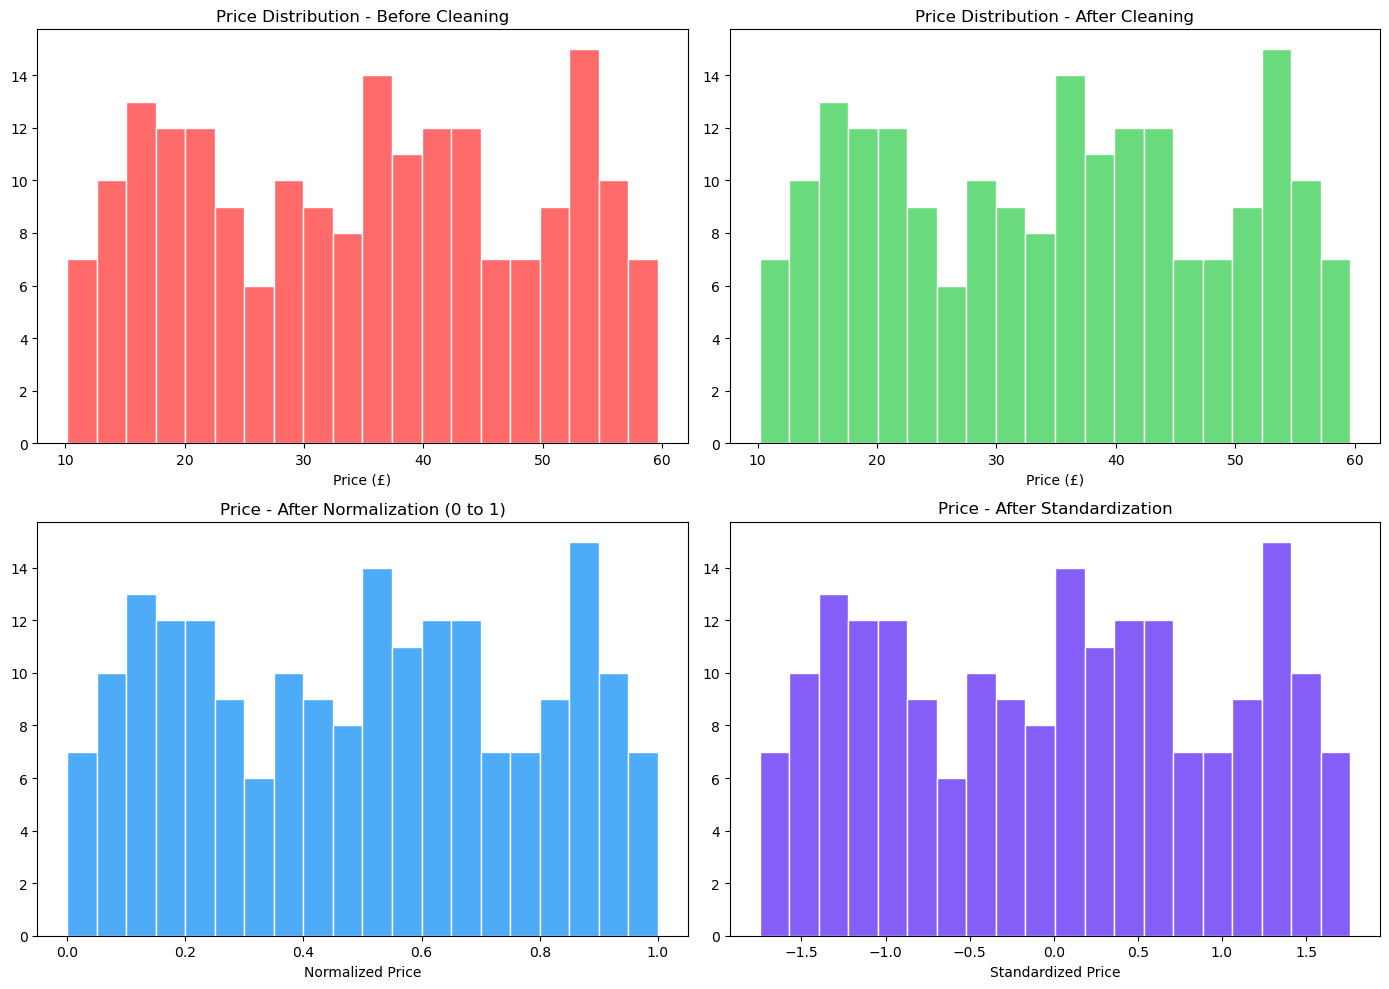

Comparison chart saved as 'cleaning_comparison.png'


In [15]:
# Visual comparison of data before and after cleaning

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original price distribution
axes[0, 0].hist(pd.read_csv(r'C:\Users\MY-PC\Documents\Internship\Level 01\books_data.csv')['Price (£)'],
                bins=20, color='#ff6b6b', edgecolor='white')
axes[0, 0].set_title('Price Distribution - Before Cleaning')
axes[0, 0].set_xlabel('Price (£)')

# Cleaned price distribution
axes[0, 1].hist(df['Price (£)'],
                bins=20, color='#69db7c', edgecolor='white')
axes[0, 1].set_title('Price Distribution - After Cleaning')
axes[0, 1].set_xlabel('Price (£)')

# Normalized price distribution
axes[1, 0].hist(df['Price_Normalized'],
                bins=20, color='#4dabf7', edgecolor='white')
axes[1, 0].set_title('Price - After Normalization (0 to 1)')
axes[1, 0].set_xlabel('Normalized Price')

# Standardized price distribution
axes[1, 1].hist(df['Price_Standardized'],
                bins=20, color='#845ef7', edgecolor='white')
axes[1, 1].set_title('Price - After Standardization')
axes[1, 1].set_xlabel('Standardized Price')

plt.tight_layout()
plt.savefig('cleaning_comparison.png', dpi=150)
plt.show()

print("Comparison chart saved as 'cleaning_comparison.png'")